In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd 
import cartopy.crs as ccrs
import cmocean
import seaborn as sns
from scipy.stats import pearsonr 
from scipy.stats import shapiro 
from scipy.stats import linregress
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from OceanDataStore import OceanDataCatalog 
from nemo_cookbook import NEMODataTree  
from matplotlib.patches import Rectangle

In [2]:
def select_by_lonlat(ds, lon_target, lat_target):
    lat = ds['gphit'].values
    lon = ds['glamt'].values
    distance = np.sqrt((lat - lat_target)**2 + (lon - lon_target)**2)
    y_idx, x_idx = np.unravel_index(np.argmin(distance), distance.shape)
    print('x index =', x_idx)
    print('y index =', y_idx)
    return (y_idx, x_idx)


In [4]:
# Open model and config files

catalog = OceanDataCatalog(catalog_name='noc-model-stac')
catalog.search(collection='noc-npd-era5', standard_name='sea_surface_temperature')
ds1_5day = catalog.open_dataset(id=catalog.Items[4].id,
                          start_datetime='1990-01',
                          end_datetime='2024-12')

catalog.search(collection='noc-npd-era5', item_name='domain_cfg')
config = catalog.open_dataset(id=catalog.Items[1].id)

# Merge into a data tree
datasets_5day = {'parent': {'domain': config, 'gridT': ds1_5day}}
dt_global_5day = NEMODataTree.from_datasets(datasets = datasets_5day)

# Clip to North Atlantic 
bbox = (-85.0, 0.0, 0.0, 80.0)
dt_5day = dt_global_5day.clip_grid(grid='/gridT', bbox=bbox)

# Convert to datasets
ds_5day = (dt_5day['/gridT']).dataset


            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn/T1y
              Title: eORCA1 ERA5v1 NPD T1y Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean physics annual mean outputs defined at T-points.
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2025-07-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn/T1m
              Title: eORCA1 ERA5v1 NPD T1m Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean physics monthly mean outputs defined at T-points.
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2025-07-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca025-era5v1/gn/T1y_3d
              Title: eORCA025 ERA5v1 NPD T1y_3d Icechunk repository
              Description: Icechunk repository containing eORCA025 ERA5v1 

In [5]:
min_region = ds_5day.sel(time_counter = ds_5day['time_counter'].dt.month.isin([2, 3, 4]))
min_temp = ((min_region['tos_con'].groupby('time_counter.year')).min(dim='time_counter')).compute()

In [9]:
min_temp.to_netcdf('min_temp_0.25.nc')

In [13]:
salinity = xr.open_dataset('../CORRELATION/salinity_ts_0.25.nc')
amplitude = xr.open_dataset('../CORRELATION/amplitude_ts_0.25.nc')
mins = xr.open_dataset('min_temp_0.25.nc')
years = np.arange(1990, 2025)

In [17]:
mins

<xarray.Dataset> Size: 26MB
Dimensions:  (year: 35, j: 482, i: 341)
Coordinates:
  * year     (year) int64 280B 1990 1991 1992 1993 1994 ... 2021 2022 2023 2024
  * j        (j) int64 4kB 685 686 687 688 689 690 ... 1162 1163 1164 1165 1166
  * i        (i) int64 3kB 809 810 811 812 813 814 ... 1145 1146 1147 1148 1149
    gphit    (j, i) float64 1MB ...
    glamt    (j, i) float64 1MB ...
Data variables:
    tos_con  (year, j, i) float32 23MB ...

x index = 145
y index = 354


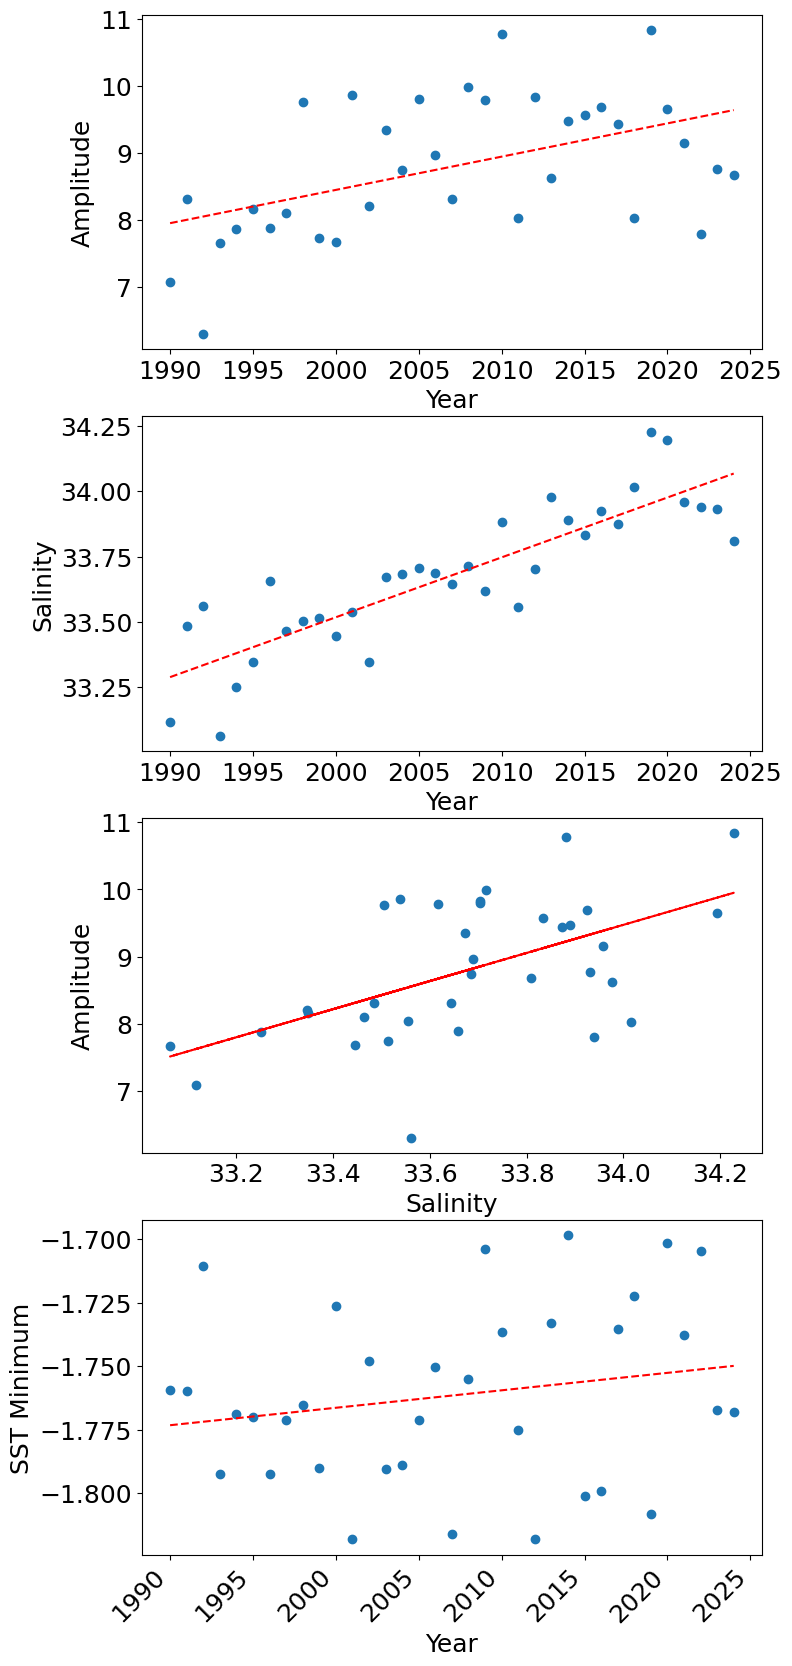

In [19]:
## ## Consider 56W, 67N

j_idx, i_idx = select_by_lonlat(amplitude, -56.0, 67.0)
amplitude_ts = amplitude.isel(j=j_idx, i=i_idx)['tos_con'].values
salinity_ts = salinity.isel(j=j_idx, i=i_idx)['sos_abs'].values
min_ts = mins.isel(j = j_idx, i = i_idx)['tos_con'].values

fig, ax = plt.subplots(4, 1, figsize = (8, 20))
ax0 = ax[0]
ax1 = ax[1]
ax2 = ax[2]
ax3 = ax[3]

ax0.scatter(years, amplitude_ts)
z = np.polyfit(years, amplitude_ts, 1)
p = np.poly1d(z)
ax0.plot(years ,p(years),"r--")
ax0.set_xlabel('Year')
ax0.set_ylabel('Amplitude')

ax1.scatter(years, salinity_ts)
z = np.polyfit(years, salinity_ts, 1)
p = np.poly1d(z)
ax1.plot(years ,p(years),"r--")
ax1.set_xlabel('Year')
ax1.set_ylabel('Salinity')

ax2.scatter(salinity_ts, amplitude_ts)
z = np.polyfit(salinity_ts, amplitude_ts, 1)
p = np.poly1d(z)
ax2.plot(salinity_ts ,p(salinity_ts),"r--")
ax2.set_xlabel('Salinity')
ax2.set_ylabel('Amplitude')

ax3.scatter(years, min_ts)
z = np.polyfit(years, min_ts, 1)
p = np.poly1d(z)
ax3.plot(years ,p(years),"r--")
ax3.set_xlabel('Year')
ax3.set_ylabel('SST Minimum')

for a in ax:
    a.tick_params(labelsize=18)
    a.xaxis.label.set_size(18)
    a.yaxis.label.set_size(18)
    
plt.xticks(rotation=45, ha='right')
plt.show()
